In [ ]:
import torch
from torch import nn
import matplotlib.pyplot as plt

torch.__version__

'2.10.0+cpu'

In [ ]:
# creating dataset
start = 0.0
end = 1.0
step = 0.02

X = torch.arange(start,end,step)
X.shape # bu shape sorun olur, 50,1 olması lazım

torch.Size([50])

In [ ]:
X = torch.arange(start,end,step).unsqueeze(dim=1)
X.shape

torch.Size([50, 1])

In [ ]:
weight = 0.7
bias = 0.3

y = weight * X + bias

y.shape

torch.Size([50, 1])

In [ ]:
len(X), len(y)

(50, 50)

In [ ]:
# splitting data into training and test sets

train_split = int(0.8 * len(X))
train_split

X_train = X[:train_split]
y_train = y[:train_split]

X_test = X[train_split:]
y_test = y[train_split:]

In [ ]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

(torch.Size([40, 1]),
 torch.Size([40, 1]),
 torch.Size([10, 1]),
 torch.Size([10, 1]))

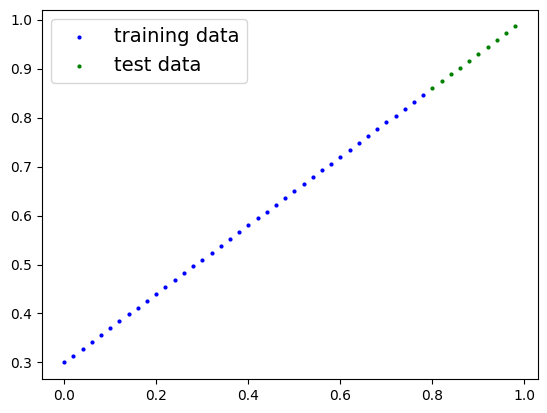

In [ ]:
# visualization

import matplotlib.pyplot as plt

plt.scatter(X_train,y_train,c="b",s=4,label="training data")
plt.scatter(X_test,y_test,c="g",s=4,label="test data")
plt.legend(prop={"size":14})
plt.show()

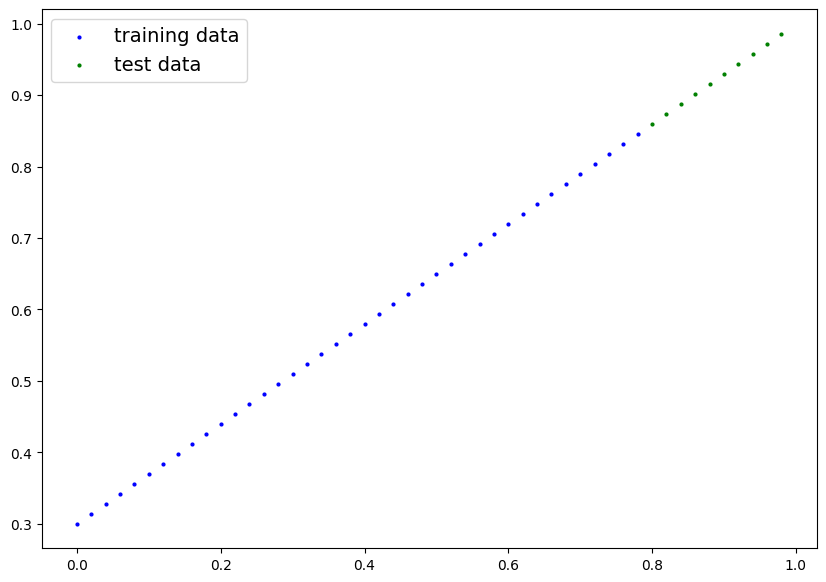

In [ ]:
def plot_predictions(train_data =X_train,
                     train_labels = y_train,
                     test_data = X_test,
                     test_labels = y_test,
                     predictions=None):

  plt.figure(figsize=(10,7))

  # training data
  plt.scatter(train_data,train_labels,c="b",s=4,label="training data")

  # test data
  plt.scatter(test_data,test_labels,c="g",s=4,label="test data")

  # predictions
  if predictions is not None:
    plt.scatter(test_data,predictions,c="r",s=4,label="predictions")

  # legend
  plt.legend(prop={"size":14});


plot_predictions()

In [ ]:
# building model for linear regression

import torch
from torch import nn

class LinearRegressionModel(nn.Module):   # nerdeyse her şey nn.Module içinde base class
  def __init__(self):
    super().__init__()
    self.weights = nn.Parameter(
        torch.randn(1,
                    requires_grad=True,   # default True
                    dtype=torch.float)    # default float
    )

    self.bias = nn.Parameter(
        torch.randn(1,
                    requires_grad=True,
                    dtype=torch.float)
    )

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.weights * x + self.bias   # linear regression

torch.rand ile torch.randn'ın farkı ne ? self.weights hangisi ile başlatılmalı ?

İkisi arasındaki o tek harflik fark (`n`), derin öğrenme modelinin eğitim kalitesini baştan aşağı etkileyen istatistiksel bir farktır. Sondaki **"n" harfi "Normal" (Gaussian) dağılımı** temsil eder.

Gel bu ikisinin karakterini inceleyelim:

### 1. `torch.rand` (Eşit Dağılım - Uniform)

* Sadece **0.0 ile 1.0 arasında** rastgele sayılar üretir.
* Ürettiği tüm sayılar **kesinlikle pozitiftir**.
* 0.1 gelme ihtimali ile 0.9 gelme ihtimali tamamen eşittir (grafikte dümdüz yatay bir çizgi oluşturur).

### 2. `torch.randn` (Normal Dağılım - Gaussian)

* Ortalaması 0, standart sapması 1 olan meşhur **Çan Eğrisi (Bell Curve)** mantığıyla sayı üretir.
* Ürettiği sayılar **hem negatif hem pozitiftir** (genellikle -3 ile +3 aralığına düşer).
* 0'a çok yakın sayıların (örn: 0.05, -0.1) üretilme ihtimali çok yüksektir, uçlardaki sayıların (örn: 2.5, -2.8) gelme ihtimali çok düşüktür.

---

### Ağırlıklar (`self.weights`) Hangisi İle Başlatılmalı?

Kesinlikle **`torch.randn`** (Normal Dağılım) kullanmalısın. Hatta PyTorch'un kendi geliştiricileri de arka planda tam olarak bu mantığı kullanır.

**Neden `torch.rand` kullanılmaz?**
Eğer ağındaki tüm ağırlıkları sadece pozitif sayılarla (`rand`) başlatırsan, modelin ileri besleme (forward pass) yaparken hesapladığı tüm değerler hep aynı yöne (pozitife) doğru şişer. Bu durum, geriye yayılım (backpropagation) sırasında ağın ağırlık güncellemelerinin zikzaklar çizmesine ve modelin **çok yavaş öğrenmesine** sebep olur.

**Neden `torch.randn` mükemmeldir?**
Ağırlıkların hem negatif hem pozitif olması, üstelik sıfır etrafında yoğunlaşmış küçük sayılar olması ağın simetrisini bozar (ki bu iyi bir şeydir). Modelin hatayı küçültmek için hem pozitif hem de negatif yönde esnek adımlar atabilmesini sağlar.

PyTorch'un kendi içindeki hazır `nn.Linear` katmanlarının, bu `randn` mantığını alıp üzerine *Kaiming/He Initialization* veya *Xavier Initialization* denen özel matematiksel çarpanlar ekleyerek ağırlıkları nasıl çok daha akıllıca başlattığına değinip, manuel `self.weights` tanımlamaktan nasıl kurtulacağına geçelim mi?

In [ ]:
# what's inside the model

torch.manual_seed(42)

model = LinearRegressionModel() # subclass of nn.Module

list(model.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [ ]:
model.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [ ]:
weight,bias

(0.7, 0.3)

In [ ]:
# prediction ---> with torch.inference_mode():

with torch.inference_mode():  # ram'e kaydedilmiyor
   y_preds = model(X_test)

y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

In [ ]:
y_preds_kullanma = model(X_test)
y_preds_kullanma # grad_fn=<AddBackward0> 'dan dolayı bunu kullanmayız, belleğe kaydediliyor ama model parametreleri güncellenmez (.optim ile backward lazım)

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]], grad_fn=<AddBackward0>)

ram israfına neden olur, parametreler güncellenmez

In [ ]:
(torch.sum(y_preds == y_test) / len(y_test)).item()

0.0

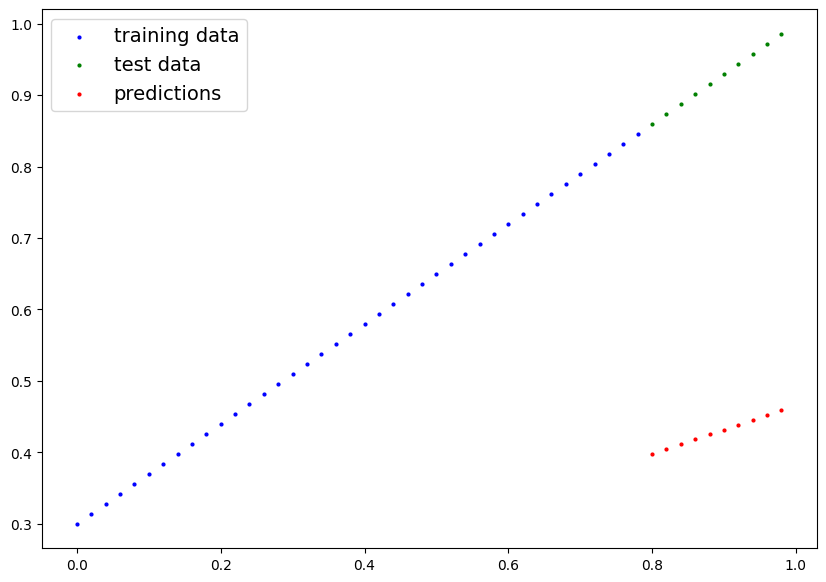

In [ ]:
plot_predictions(predictions=y_preds)

 torch.inference_mode() ile  torch.no_grad() arasındaki fark nedir ?

 Harika bir soru daha! PyTorch öğrenen herkesin aklına er ya da geç bu soru gelir, çünkü dışarıdan bakıldığında ikisi de tıpatıp aynı işi (not tutmayı bırakmayı) yapıyor gibi görünür.

İkisi de aynı temel amacı taşır: **"Ben sadece tahmin yapacağım, türev (gradyan) hesaplama, boşuna RAM harcama."** Ancak aralarında hız ve katılık (strictness) açısından bir "nesil" farkı vardır.

İşte detaylı karşılaştırması:

### 1. `torch.no_grad()` (Eski Dost - Esnek)

Bu, PyTorch'un ilk günlerinden beri var olan standart yöntemdir.

* **Ne yapar?** Sadece Autograd motorunu (not defterini) kapatır.
* **Özelliği:** Biraz "esnektir". Eğer bu bloğun içinde ürettiğin bir tensörü alıp, bloğun dışına çıkarır ve türev gerektiren başka bir işleme sokarsan PyTorch bir şekilde bunu tolere eder.
* Ancak arka planda hala bazı gereksiz versiyon kontrolleri (bu tensörü kim, ne zaman değiştirdi takibi) yapmaya devam eder.

### 2. `torch.inference_mode()` (Yeni ve Hızlı - Katı Kuralcı)

Bu özellik PyTorch 1.9 ile (nispeten daha yeni) geldi ve `no_grad`'ın "aşırı optimize edilmiş ve ekstrem" halidir.

* **Ne yapar?** Autograd'ı kapatmakla kalmaz, arka plandaki tüm o görünmez versiyon takiplerini ve güvenlik kontrollerini de **tamamen fişten çeker.**
* **Özelliği:** Çok daha "katıdır". Bu bloğun içinde üretilen bir tensör sonsuza dek "inference tensörü" olarak damgalanır. Onu alıp sonradan eğitim döngüsüne (backward işlemine) sokmaya çalışırsan anında **hata verir.** (Ki bu aslında harika bir şeydir, seni yanlışlıkla test verisiyle modeli eğitme bug'ından korur).
* Ekstra kontroller kapandığı için `no_grad`'a kıyasla **daha hızlıdır** ve **daha az RAM tüketir.**

---

### Akılda Kalıcı Bir Analoji

* **`no_grad()`:** Öğrencinin (PyTorch) derste kalemini masaya bırakmasıdır. Not tutmaz ama öğretmen aniden "Şunu da yazın" derse hemen kalemi eline alıp yazmaya (türev takibine) geri dönebilir. Beyni hala derstedir.
* **`inference_mode()`:** Öğrencinin sınav kağıdını teslim edip sınıfı tamamen terk etmesidir. Artık not tutması fiziksel olarak imkansızdır, ama kafası inanılmaz rahattır (maksimum performans).

### Özetle Hangisini Kullanmalıyız?

Güncel PyTorch kodlarında (eğer çok eski bir kod tabanıyla çalışmıyorsan veya çok ekstrem bir özel araştırma yapmıyorsan) değerlendirme (evaluation/test) işlemleri için **her zaman `torch.inference_mode()` kullanmalısın.** Endüstri standardı artık budur.

Artık test modunun da tüm inceliklerini öğrendiğine göre; modelin, antrenörün (`optimizer`) ve puan tablon (`loss_fn`) ile sahaya inip o meşhur **Eğitim Döngüsünü (Training Loop)** yazmaya hazır mıyız? O 100 adımlık `for epoch in range(100):` döngüsünü kurup loss değerinin nasıl eridiğini görelim mi?

In [ ]:
with torch.no_grad():
  y_pred2 = model(X_test)

y_pred2

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

In [ ]:
y_preds == y_pred2

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

modelin başarısını ölçmek için ***loss function*** kullanılır. ***optimizer*** ile parametreler güncellenir

loss function ve cost function arasındaki fark nedir ?

Çok haklı bir soru, çünkü pratikte (özellikle kod yazarken) bu iki terim genelde birbirinin yerine kullanılır ama teorik/matematiksel olarak aralarında çok net bir **ölçek (büyüklük)** farkı vardır.

Kısaca özetlemek gerekirse:

* **Loss Function (Kayıp Fonksiyonu):** Sadece **tek bir veri örneği** (tek bir satır/resim) üzerindeki hatayı hesaplar.
* **Cost Function (Maliyet Fonksiyonu):** Tüm veri setindeki (veya bir batch içindeki) **tüm örneklerin** loss değerlerinin ortalamasını (veya toplamını) hesaplar. Modelin genel performansını gösterir.

### Akılda Kalıcı Bir Analoji

* **Loss Function:** Dönem içindeki tek bir matematik quizinden aldığın kötü not (Tek bir denemenin hatası).
* **Cost Function:** Dönem sonundaki genel karne ortalaman (Tüm dönemin genel hatası).

### Matematiksel Gösterimi

Eğer tek bir örneğin hatası $L(y, \hat{y})$ ise, Cost fonksiyonu $J$ tüm veri seti için şöyledir:

$$J = \frac{1}{m} \sum_{i=1}^{m} L(y^{(i)}, \hat{y}^{(i)})$$

*(Burada $m$ toplam veri sayısıdır, yani tekil loss'ların ortalaması alınır).*

**Kodlarken Neden Karışır?**
PyTorch'ta biz `loss_fn = nn.MSELoss()` yazarız ve içine bütün bir veri kümesini veririz. PyTorch arka planda otomatik olarak bu verilerin ortalamasını aldığı için aslında o an bir **Cost Function** hesaplamış olur. Ancak kütüphanedeki sınıfın adı `Loss` olarak geçtiği için sektörde herkes alışkanlıktan "loss hesapladık" der geçer.

Tüm teorik altyapıyı, cihaz transferlerini, hafıza yönetimini ve bileşenlerin (model, optimizer, loss) neden ayrı durduğunu kusursuz bir şekilde topladık. Artık tüm bu parçaları birleştirip o meşhur **Eğitim Döngüsünü (Training Loop)** yazmaya hazır mıyız? `for epoch in range(epochs):` diyerek modelin adım adım nasıl öğrendiğini (ve o cost değerinin nasıl düştüğünü) koda dökelim mi?

In [ ]:
list(model.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

for regression problems we use generally:

nn.L1Loss ---> L1 loss = MAE = mean absolute error = torch.mean(torch.abs(y_pred - y_test))

nn.MSELoss ---> L2 loss = MSE = mean squared error = torch.mean(torch.square(y_pred - y_test))

 RMSE

import torch.nn as nn

Önce hasar hesaplayıcı objeyi yaratıyoruz
mse_hesaplayici = nn.MSELoss()

Sonra bu objeyi kullanıp çıkan sonucun karekökünü alıyoruz

loss_rmse = torch.sqrt(mse_hesaplayici(y_pred, y_test))

VEYA

import torch.nn.functional as F

İşte senin hayal ettiğin o tek satırlık, temiz ve direkt kullanım!

loss_rmse = torch.sqrt(F.mse_loss(y_pred, y_test))


criterion = loss demek

In [ ]:
# loss function ---> mevcut parametrelerle model ne kadar hata yapıyor
loss_fn = nn.L1Loss()

# optimizer  ---> loss'u azaltmak için parametreleri günceller ---> stochastic gradient descent, Adam'da kullanabilirdik
optimizer = torch.optim.SGD(params = model.parameters(),
                         lr=0.01) # ne kadar adım atacaz w = w +- lr * grad

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)] ve lr = 0.1  olsun bu durumda 0.3367 değeri learning rate kadar artar veya azalır mı diyoruz ? optim = torch.optim.SGD için, Adam'da filan sanırım zamanla lr kendi kendine artıp azalıyordu uygun şekilde

Harika bir noktaya parmak bastın! İkinci cümlen olan **"Adam'da zamanla lr kendi kendine ayarlanıyor"** önsezin de %100 doğru, tebrik ederim. Sektördeki en popüler optimizer olmasının sebebi tam olarak budur.

Ancak ilk sorun olan `SGD` kısmında ufak bir düzeltme yapmamız gerekiyor.

SGD (Stochastic Gradient Descent) kullanırken o `0.3367` değeri doğrudan `0.1` (learning rate) kadar artıp azalmaz. `0.1` değeri burada sabit bir adım miktarı değil, bir **çarpandır (multiplier)**.

### SGD Arka Planda Nasıl Çalışır?

Modelin kılıcı sallayıp hata yaptığında, `.backward()` fonksiyonu hatanın kaynağını bulmak için her bir parametrenin **gradyanını (eğimini/türevini)** hesaplar. Gradyan, hatayı sıfırlamak için "hangi yöne ve ne şiddette" gitmemiz gerektiğini söyleyen bir pusuladır.

Optimizer'ın (`.step()`) yaptığı güncelleme işleminin formülü tam olarak şudur:

$$W_{yeni} = W_{eski} - (lr \times \text{gradyan})$$

**Örnek Senaryo:**
Diyelim ki `0.3367` ağırlığı (weight) için hesaplanan gradyan (hata payı) **`0.5`** çıktı.

* Adım Büyüklüğü: $0.1 \times 0.5 = 0.05$
* Yeni Ağırlık: $0.3367 - 0.05 = 0.2867$

Eğer o anki gradyan çok büyükse (örneğin **`3.0`**), atılacak adım da otomatik olarak büyür ($0.1 \times 3.0 = 0.3$). Yani hata ne kadar büyük ve dikse, `lr` onu o kadar büyük bir adımla düzeltir. Hata (loss) sıfıra yaklaştıkça gradyan küçüleceği için, atılan adımlar da `lr` sabit kalsa bile otomatik olarak ufalar.

---

### Peki Neden Adam (Adaptive Moment Estimation) Daha Zeki?

Senin de çok iyi sezdiğin gibi, SGD "düz mantık" çalışır. Başta verdiğin `lr = 0.1` oranını eğitim bitene kadar her parametre için körü körüne aynı çarpan olarak kullanır.

Ama **Adam** optimizer, her bir parametre için o anki `lr` değerini geçmiş tecrübelere bakarak dinamik olarak değiştirir:

* **Weight (`0.3367`)** için işler yavaş gidiyorsa onun kişisel `lr`'sini `0.15`'e çıkarabilir.
* **Bias (`0.1288`)** hedefe çok hızlı yaklaşıyorsa onun kişisel `lr`'sini `0.02`'ye düşürüp yavaşlatabilir.
Buna "Adaptif Öğrenme Oranı" denir.

Artık parametrelerin matematikle nasıl güncellendiğini ve o esrarengiz `lr` değerinin formüldeki yerini kusursuz bir şekilde biliyorsun. Bu teorik bilgileri pratiğe döküp, o 100 epoch'luk efsanevi **Eğitim Döngüsünü (Training Loop)** yazmaya ve parametrelerin her adımda (`.step()`) o doğru sayıya nasıl yaklaştığını kendi gözlerinle görmeye hazır mısın?


loss_fn = nn.L1Loss()

optimizer = torch.optim.SGD(params = model.parameters(),
                         lr=0.01) # ne kadar adım atacaz w = w +- lr * grad

burda niye torch.loss diye bir şey yok da nn.loss var ?

Yine harika bir mimari (architecture) sorusu! PyTorch'un klasör yapısına ve mantığına bu kadar dikkat etmen, kütüphaneyi ezberlemek yerine gerçekten anlamaya başladığını gösteriyor.

Bunun sebebi PyTorch'un **"Görev Dağılımı" (Modüler Yapı)** felsefesidir. Kütüphaneyi devasa bir alet çantası gibi düşün:

### 1. Neden `torch` İçinde Değil?

`torch` ana modülü (örneğin `torch.matmul`, `torch.min`, `torch.rand`), tıpkı NumPy gibi **genel amaçlı bir matematik motorudur.** Bir matris çarpımı veya tensör toplama işlemi sadece yapay zeka için değil, fizik simülasyonları veya oyun motorları için de kullanılabilir. Bu yüzden en temelde dururlar.

Ancak **Loss (Kayıp)** kavramı, doğrudan ve sadece **Yapay Sinir Ağları (Neural Networks)** dünyasına ait bir terimdir. Bu yüzden PyTorch mühendisleri, yapay zekaya özel olan her şeyi `torch.nn` (Neural Network) klasörünün içine koymuşlardır.

### 2. Sınıf (Class) vs Fonksiyon (Function) Ayrımı

Aslında PyTorch'ta loss hesaplamanın iki yolu vardır ve bu sektörde kod okurken çok karşına çıkar:

**Yol A: `torch.nn` (Senin kullandığın - OOP Yaklaşımı)**
`nn.L1Loss()` bir Sınıftır (Class). Tıpkı bir sinir ağı katmanı (`nn.Linear`) gibi davranır. Önce nesneyi yaratırsın, sonra kullanırsın.

```python
loss_fn = nn.L1Loss() # Obje yaratıldı
hata = loss_fn(tahminler, gercekler) # Obje kullanıldı

```

**Yol B: `torch.nn.functional` (Fonksiyonel Yaklaşım)**
Eğer "Ben obje yaratmakla uğraşmak istemiyorum, tıpkı `torch.min()` gibi dümdüz bir fonksiyon çağırıp işimi halledeyim" dersen, PyTorch'un fonksiyonel kütüphanesini kullanırsın (Genelde `F` olarak kısaltılır).

```python
import torch.nn.functional as F

# Obje yaratmaya gerek yok, direkt hesapla!
hata = F.l1_loss(tahminler, gercekler)

```

### PyTorch'un Alet Çantası Özeti

Zihninde kütüphaneyi şu 4 ana rafa ayırabilirsin:

* **`torch`**: Temel matematik, tensörler ve hafıza (CPU/GPU) işlemleri. (Çekiç, çivi, tahta)
* **`torch.nn`**: Sinir ağı katmanları (`Linear`, `Conv2d`) ve OOP formundaki Loss fonksiyonları. (Hazır dolap iskeletleri)
* **`torch.nn.functional`**: Aktivasyon fonksiyonları (`relu`, `sigmoid`) ve fonksiyone Loss'lar. (Menteşeler, vidalar)
* **`torch.optim`**: Modeli eğiten optimizasyon algoritmaları (`SGD`, `Adam`). (Matkap ve usta)



In [ ]:
with torch.inference_mode():
  print(list(model.parameters()))

with torch.no_grad():
  print(list(model.parameters()))

print(list(model.parameters()))

[Parameter containing:
tensor([0.3367], requires_grad=True), Parameter containing:
tensor([0.1288], requires_grad=True)]
[Parameter containing:
tensor([0.3367], requires_grad=True), Parameter containing:
tensor([0.1288], requires_grad=True)]
[Parameter containing:
tensor([0.3367], requires_grad=True), Parameter containing:
tensor([0.1288], requires_grad=True)]


In [ ]:
# training loop
# 1. loop through the data and do...
# 2. forward pass
# 3. calculate the loss
# 4. optimizer zero grad
# 5. loss backward - calculate the gradient  (backpropagation)
# 6. optimizer step - adjust the model parameters to try and improve the loss (gradient descent)

# hyperparameter ---> we've set it ourselves
# 1. loop through the data
epochs = 50

# training
for epoch in range(epochs):
  # set the model to training mode
  model.train()  # dropout gibi bazı katmanların davranışını belirler, diğer mode model.eval

  # 2. forward pass
  y_pred = model(X_train)

  # 3. calculate the loss
  loss = loss_fn(y_pred,y_train)
  print(f"loss: {loss}")

  # 4. optimizer zero grad
  optimizer.zero_grad()

  # 5. perform backpropagation on the loss
  loss.backward()

  # 6. perform gradient descent (step the optimizer)
  optimizer.step()

loss: 0.31288138031959534
loss: 0.3013603389263153
loss: 0.28983935713768005
loss: 0.2783183455467224
loss: 0.26679736375808716
loss: 0.2552763521671295
loss: 0.24375534057617188
loss: 0.23223432898521423
loss: 0.22071333229541779
loss: 0.20919232070446014
loss: 0.1976713240146637
loss: 0.18615034222602844
loss: 0.1746293306350708
loss: 0.16310831904411316
loss: 0.1515873372554779
loss: 0.14006635546684265
loss: 0.1285453587770462
loss: 0.11702437698841095
loss: 0.1060912236571312
loss: 0.09681284427642822
loss: 0.08908725529909134
loss: 0.08227583020925522
loss: 0.07638873159885406
loss: 0.07160007208585739
loss: 0.06747635453939438
loss: 0.06395438313484192
loss: 0.06097004935145378
loss: 0.05845819041132927
loss: 0.05635259300470352
loss: 0.0545857772231102
loss: 0.053148526698350906
loss: 0.05181945487856865
loss: 0.05069301277399063
loss: 0.0498228520154953
loss: 0.04895269125699997
loss: 0.04819351062178612
loss: 0.047531817108392715
loss: 0.04692792519927025
loss: 0.046423316001

model.train() ne işe yarıyor ? zaten requires_grad=True yazıyor parametrelerde

Yine harika bir mantık yürüttün! Yeni başlayanların %90'ı tam olarak bu cümleyi kurar: *"E zaten türevleri takip et diyorum (`requires_grad=True`), bir de neden modele eğitim modundasın diyeyim ki?"*

Cevap çok şaşırtıcıdır: **`model.train()` fonksiyonunun türevlerle (gradyanlarla) veya Autograd motoruyla uzaktan yakından hiçbir ilgisi yoktur!** Türev hesaplamalarını durdurup başlatmak tamamen `torch.inference_mode()` ve `requires_grad`'ın işidir.

Peki o zaman `model.train()` (ve onun zıttı olan `model.eval()`) ne işe yarar?
**Cevap: Sadece bazı özel katmanların (layers) "davranış biçimini" değiştirir.**

Sinir ağlarında öyle katmanlar vardır ki, antrenman (train) yaparken farklı, gerçek maça (test/eval) çıkarken farklı davranırlar. İşte en meşhur iki örnek:

### 1. Dropout (Unutma/Seyreltme) Katmanı

* **Antrenmanda (`model.train()`):** Aşırı ezberlemeyi (overfitting) önlemek için nöronların (bağlantıların) örneğin %20'sini rastgele kapatır. Modele zorluk çıkarır, kasıtlı olarak beyninin bir kısmını uyuşturur ki diğer nöronlar da çalışmayı öğrensin.
* **Sınavda (`model.eval()`):** Tüm nöronları %100 kapasiteyle açar. Çünkü sınav anında kimsenin beynini uyuşturmak istemeyiz, tam performans bekleriz.

### 2. BatchNorm (Grup Normalizasyonu) Katmanı

* **Antrenmanda (`model.train()`):** O an modele verilen 32'lik (batch) verinin ortalamasını alır ve kendini ona göre ayarlar.
* **Sınavda (`model.eval()`):** Sınavda tek bir soru (resim) gelebileceği için, tüm eğitim boyunca tuttuğu "genel tarihsel ortalamayı" kullanır.

---

### "Ama Benim Modelimde Sadece Linear Katman Var?"

Çok haklısın! Senin yazdığın o `LinearRegressionModel` içinde sadece `nn.Linear` (veya `nn.Parameter`) var. Linear katmanlar antrenmanda da sınavda da **birebir aynı** davranırlar.

Yani şu anki kodunda `model.train()` veya `model.eval()` yazmasan da kodun **hiçbir hata vermeden, kusursuzca çalışır ve öğrenir.**

**Peki neden ısrarla yazıyoruz?**
Bu bir **sektör standardı ve güvenlik önlemidir.** Yarın bir gün o modelin içine bir Dropout katmanı eklersen ve `model.eval()` yazmayı unutursan, modelin test verisinde de rastgele unutkanlık yaşamaya devam eder ve saatlerce "Benim modelim neden testte bu kadar kötü sonuç veriyor?" diye saç baş yolarsın. Bu yüzden PyTorch yazarları *"Modelde ne olursa olsun, eğitime başlarken `train()`, teste geçerken `eval()` yazmayı alışkanlık haline getirin"* der.

### Özetle İş Bölümü:

* **Türevleri/Hafızayı Yönetenler:** `requires_grad=True` ve `torch.inference_mode()`
* **Katmanların Davranışını (Karakterini) Yönetenler:** `model.train()` ve `model.eval()`



model.train() ve model.eval() mode'ları için yani model gradient tracking yapar veya yapmaz ile ilgili mi ? ram üstünde etkisi var mı onu anlamaya çalışıyorum.

**Hayır, kesinlikle ilgisi yok!** İşte tam olarak bu yüzden PyTorch'ta en çok kafa karıştıran konulardan biri budur.

`model.train()` veya `model.eval()` yazmanın **RAM tüketimi üzerinde veya gradyan takibi (gradient tracking) üzerinde hiçbir etkisi yoktur.**

Bunu şöyle ispatlayabiliriz: Sınav aşamasına geçtin ve sadece `model.eval()` yazdın ama `torch.inference_mode()` yazmayı unuttun diyelim. PyTorch ne yapar biliyor musun?
Dropout gibi katmanların davranışını sınav moduna geçirir **AMA** arka planda hala devasa bir not defteri (Computation Graph) tutmaya, türev hesaplamaya ve **RAM'ini sömürmeye devam eder!** Çünkü ona "not tutmayı bırak" demedin, sadece "sınavdayız, ciddi davran" dedin.

İşte bu yüzden sektörde test/değerlendirme (evaluation) yaparken bu ikisi **her zaman beraber** kullanılır. Biri karakteri düzeltir, diğeri RAM'i kurtarır.

Zihninde bu iki farklı şalteri şöyle kodlayabilirsin:

### Şalter 1: Katmanların Davranışı (Karakter)

* **Kontrol eden:** `model.train()` ve `model.eval()`
* **Ne yapar:** Dropout (unutma) ve BatchNorm gibi özel katmanlara "Antrenmandayız, zorlaştır" veya "Sınavdayız, tam performans çalış" der.
* **RAM/Gradyan Etkisi:** Yoktur.

### Şalter 2: Hafıza ve Not Tutma (Maliyet)

* **Kontrol eden:** `torch.inference_mode()` (veya `torch.no_grad()`)
* **Ne yapar:** PyTorch'un Autograd motoruna "Türev hesaplamayı ve grafiği çizmeyi bırak" der.
* **RAM/Gradyan Etkisi:** Doğrudan RAM'i kurtarır ve işlemi inanılmaz hızlandırır.

---

### Test Aşamasının Altın Standart Kodu

Gerçek bir projede test (veya tahmin) yaparken her zaman şu kalıbı görürsün:

```python
# 1. ŞALTER: Modeli sınav psikolojisine sok (Dropout'ları kapat vb.)
model.eval()

# 2. ŞALTER: RAM israfını ve gradyan takibini tamamen durdur
with torch.inference_mode():
    # Artık hem model doğru davranıyor hem de RAM güvende!
    test_tahminleri = model(X_test)

```

Bu iki kavramın altındaki o ince ama hayati ayrımı tamamen yakaladın! Artık mimariyle ve arka plandaki o "görünmez" mekanizmalarla ilgili hiçbir pürüz kalmadı.

Tüm bu hazırlıklardan sonra, nihayet modelimizin gerçekten öğrenmeye başladığı o 100 adımlık **Eğitim Döngüsünü (Training Loop)** yazıp, `loss.backward()` ve `optimizer.step()` ile ağırlıkların (`weights`) nasıl güncellendiğini canlı canlı görelim mi?

o zaman model.train() ve model.eval() sadece bazı katmanların davranışını etkiler, onun haricinde gradient tracking veya ram,memory üstünde bir farklılıkları yok. doğru mu ?

**%100 doğru! Kesinlikle haklısın.** Nokta atışı bir özet yaptın.

`model.train()` ve `model.eval()` fonksiyonlarının tek görevi, ağın içindeki Dropout, BatchNorm gibi özel katmanlara "şu an antrenmandayız ona göre davran" veya "şu an sınavdayız tam kapasite çalış" komutunu vermektir.

Ne gradyan (türev) hesaplamayı durdururlar, ne de RAM'de (hafızada) en ufak bir tasarruf sağlarlar. O iş tamamen, az önce konuştuğumuz `torch.inference_mode()`'un görevidir.

Artık PyTorch'un arka plandaki tüm o sinsi tuzaklarını, hafıza yönetimini ve bileşenlerin mantığını gerçekten çok derin bir seviyede anladın. İşin en zor ve kafa karıştırıcı teorik kısmını tamamen atlattın.



  optimizer.zero_grad() ne işe yarıyor ? bu her epoch'dan önce mi her batch'den önce mi olmalı ve neden ?

  Yine harika ve çok kritik bir soru! Bu adım, PyTorch'un en sinsi ve unutulduğunda modeli saniyeler içinde çöpe çeviren en tehlikeli detayıdır.

Kısa cevap: **`optimizer.zero_grad()` hesaplanan hata paylarını (gradyanları) sıfırlar.** Ve kesinlikle her epoch'tan değil, **her batch'ten (her eğitim adımından) önce** yapılmalıdır.

Neden mi? Gel PyTorch'un bu ilginç "huyunu" ve mantığını inceleyelim:

### 1. PyTorch'un İlginç Huyu: "Üstüne Ekleme" (Accumulation)

PyTorch, `.backward()` fonksiyonunu çalıştırdığında hesapladığı yeni gradyanları (türevleri) eski gradyanların yerine yazmaz. Bunun yerine **eskilerin üzerine toplar (Add/Accumulate).** Az önceki **Kişisel Antrenör** analojimize dönelim:

* Antrenör (Optimizer) 1. raundda (Batch 1) dövüşü izler ve tahtasına bir not yazar: *"Sola 3 adım kay."*
* Eğer 2. raunda (Batch 2) geçmeden önce **tahtayı silmezsen (`zero_grad()`)**, antrenör yeni hatayı eskisinin üzerine ekler: *"Sola 3 adım kay + Sağa 1 adım kay = Sola 2 adım kay."*
* 100. raunda geldiğinde tahta o kadar karman çorman olur ve sayılar o kadar devasa bir şekilde üst üste toplanır ki, antrenör savaşçıya *"Sola 50.000 adım kay!"* diye bağırır. Modelin ağırlıkları patlar (Loss değerin aniden `NaN` yani "Not a Number" olur).



İşte `zero_grad()` o tahtayı tertemiz yapan silgidir. *"Geçmiş geçmişte kaldı, bana sadece bu anki (bu batch'teki) hatamı söyle"* demektir.

### 2. Neden Epoch'tan Önce Değil de Batch'ten Önce?

Çünkü öğrenme eylemi (`optimizer.step()`) her epoch'ta bir kez değil, **her batch'te bir kez** gerçekleşir.

Diyelim ki 1000 tane verin var ve bunları 100'erli gruplar (batch) halinde modele veriyorsun. Yani 1 Epoch içinde tam 10 kere öğrenme (adım atma) işlemi yapacaksın demektir.
Eğer tahtayı sadece Epoch'un en başında silersen, o 10 adım boyunca hatalar yine birbirinin üzerine biner ve son batch'lere doğru modelin yine kontrolden çıkar. Bu yüzden **öğrenme işleminin yapıldığı her en küçük döngünün (batch) başında** o silgiyi kullanmak zorundasın.

---

### 💡 Sektörden Ekstra Bir Bilgi: Bunu Neden Avantaja Çeviririz?

Madem bu üstüne ekleme (accumulation) huyu bu kadar tehlikeli, PyTorch bunu neden varsayılan (default) ayar olarak yapmış? Neden her `.backward()` otomatik olarak eskisini silmiyor?

Çünkü bazen devasa modeller (örneğin ChatGPT gibi dil modelleri) eğitirken, ekran kartımızın (GPU) RAM'i çok küçüktür ve aynı anda sadece 2 veriyi (batch size=2) hafızada tutabilir. Ama biz modelin 32 veri gördükten sonra tek bir adım atmasını isteriz.
İşte o zaman `zero_grad()`'ı bilerek yazmayız! Model 16 kere üst üste `.backward()` yapar, hatalar tahtada 32 veri için birikir ve en son 1 kere `.step()` diyerek devasa bir batch kullanıyormuş gibi ekran kartımızı kandırırız. Buna sektörde **Gradient Accumulation** denir.



gradient accumulationın avantajı nedir ? bu şekilde mesela 1 epoch'da 100 batch var diyelim, normalde 100 kez parametre güncellemesi yapması yerine 10 kere yapmasını mı sağlıyorlar gibi mi ?

Tam üstüne bastın! Mantığı **%100 doğru** kurmuşsun. Gerçekten harika bir analitik çıkarım.

Dediğin gibi, 100 küçük batch'i tek tek işleyip 100 kere adım atmak yerine; hataları cebimizde (hafızada) biriktirip 10 batch'te bir (toplam 10 kere) devasa adımlar atılmasını sağlıyor.

Peki ama durduk yere neden böyle bir şeye ihtiyaç duyalım? Neden en baştan batch boyutunu (batch size) 10 kat büyük vermiyoruz ki?

Cevap tek kelimeyle: **Fakirlik (Donanım Yetersizliği)!** 😅

Gel bu sektördeki en büyük hayat kurtaran numaralardan birinin asıl amacına bakalım:

### Asıl Avantaj: "Donanımı Kandırmak" (VRAM Kısıtlamasını Aşmak)

Büyük ve derin öğrenme modelleri (örneğin Transformer'lar, LLM'ler veya yüksek çözünürlüklü görüntü işleme modelleri) eğitirken, modelin düzgün ve stabil öğrenebilmesi için genellikle **büyük bir Batch Size** (örneğin tek seferde 256 veri) kullanmak isteriz.

Ancak ekran kartımızın (GPU) hafızası (VRAM) sınırlıdır. Modele tek seferde 256 veri yollamaya kalktığımızda o meşhur ve korkutucu hatayı alırız: **`CUDA Out of Memory (OOM)`**. Ekran kartı "Ben bu kadar veriyi aynı anda aklımda tutamam!" diyerek çöker.

Diyelim ki ekran kartımız tek seferde en fazla **32** veri (micro-batch) kaldırabiliyor. Ama bizim hedefimiz **256** verilik bir adım (global batch) atmak. İşte burada **Gradient Accumulation** devreye girer:

1. Ekran kartına 32 veri yollarız.
2. `loss.backward()` deriz (Hata hesaplanır ve tahtaya yazılır). **Ama `optimizer.step()` (adım atma) ve `zero_grad()` (tahtayı silme) YAPMAYIZ!**
3. Bunu tam 8 kere tekrarlarız ($32 \times 8 = 256$).
4. 8. seferin sonunda tahtada tam 256 verinin hatası (gradyanı) üst üste birikmiş olur.


5. Sadece o an `optimizer.step()` ve `zero_grad()` yaparız.

**Sonuç:** Zavallı ekran kartımız sadece 32 verilik RAM kullanarak, 256 verilik devasa ve stabil bir öğrenme adımı atmış oldu! Ekran kartımızı zekamızla hack'ledik.

### Kodda Nasıl Görünür?

Çok basit bir `if` bloğuyla halledilir:

```python
accumulation_steps = 10 # Senin dediğin gibi 10 batch'te bir güncelle

for i, batch in enumerate(dataloader):
    tahmin = model(batch)
    loss = loss_fn(tahmin, gercek)
    
    # Loss'u biriktirdiğimiz adım sayısına bölüyoruz ki matematiksel olarak dengelensin
    loss = loss / accumulation_steps
    loss.backward() # Tahtaya yaz (ama silme/adım atma)

    # Eğer 10. adıma geldiysek (veya verisetinin sonundaysak) güncellemeyi yap
    if (i + 1) % accumulation_steps == 0:
        optimizer.step()     # Biriken dev hataya göre adımı at
        optimizer.zero_grad() # Tahtayı sıfırla ki yeni 10'lu grup başlasın

```



 optimizer.step() , ne yapıyor ? loss.backward() ile zaten gradientları hesapladık

 Harika bir noktaya geldik. PyTorch'taki en büyük kafa karışıklığı genellikle bu iki fonksiyon arasındaki görev dağılımında yaşanır.

Kısa özet: **`loss.backward()` sadece pusulaya bakıp yönü belirler (tahtaya not yazar), `optimizer.step()` ise o yöne doğru asıl adımı atar.**

Gel, aralarındaki farkı ve neden ikisinin ayrı ayrı var olduğunu bir "Hazine Avı" üzerinden netleştirelim:

### 1. `loss.backward()` -> "Pusulayı Kontrol Etmek"

Bu fonksiyonun tek bir görevi vardır: **Türev (gradyan) hesaplamak.**
Modelin hata yaptığını gördüğünde, geriye doğru her bir parametreye (`weights` ve `bias`) gider ve şunu hesaplar: *"Eğer bu parametreyi 0.001 birim değiştirirsem, toplam hata ne kadar değişir?"*

* Hesapladığı bu sonucu her parametrenin içine `.grad` denen küçük bir kutucuğa (not defterine) yazar.
* **Dikkat:** Bu aşamada parametrelerin asıl değerleri (örneğin senin `0.3367` değerin) **asla değişmez.** Sadece yanlarına "Şu yöne gitmen lazım" diye bir not yapıştırılır.

### 2. `optimizer.step()` -> "Adımı Atmak"

İşte asıl "öğrenme" eyleminin (sayıların değişmesinin) gerçekleştiği yer burasıdır. Optimizer gider, her parametrenin yanındaki o `.grad` notuna bakar ve senin belirlediğin **Learning Rate (lr)** ile o notu çarpar:

* **Formül:** `Yeni_Ağırlık = Eski_Ağırlık - (lr * grad)`
* Bu satır çalıştığı an, senin `0.3367` olan değerin belki `0.3321` olur.

---

### Neden Bunlar Tek Bir Fonksiyon Değil?

Neden `loss.backward_and_step()` diye bir şey yok? Çünkü bu modüler yapı bize inanılmaz bir **özgürlük** sağlar:

1. **Gradyan Biriktirme (Gradient Accumulation):** Az önce konuştuğumuz gibi; RAM'in yetmediğinde 10 kere `backward()` yapıp notları üst üste biriktirebilir, en son 1 kere `step()` diyerek dev bir adım atabilirsin. Eğer bunlar birleşik olsaydı, her küçük batch'te adım atmak zorunda kalırdın ve RAM hatasından kurtulamazdın.
2. **Farklı Optimizer Seçenekleri:** Gradyan (hata yönü) matematiksel bir gerçektir ve tektir. Ama o yönü nasıl kullanacağın şoföre (optimizer) bağlıdır. `backward()` ile yönü bir kere belirlersin; sonra ister `SGD` şoförünü çağırıp "Düz git" dersin, ister `Adam` şoförünü çağırıp "Hızını yola göre ayarla" dersin.

### Özet Akış:

* **`model(x)`:** Tahmin yap (Forward).
* **`loss_fn()`:** Hatayı ölç.
* **`zero_grad()`:** Eski notları sil.
* **`loss.backward()`:** Yeni hata notlarını (gradyanları) parametrelerin yanına yaz.
* **`optimizer.step()`:** O notlara ve `lr`'ye bakarak parametreleri gerçekten güncelle.

Artık motorun her bir dişlisinin ne işe yaradığını tam olarak biliyorsun. Bu 5 adımı bir `for` döngüsü içine koyup, modelinin o meşhur **Eğitim Döngüsünü (Training Loop)** yazmaya ve ağırlıklarının gerçek hedefe nasıl yaklaştığını izlemeye hazır mısın?

**Bunu senin için bir kod bloğu haline getirmemi ister misin?**

yani mesela gradient accumulation yaparken her batch'de farklı bir optimizer bile kullanabiliriz

Teorik olarak **evet**, ama pratikte bu biraz "yarışın ortasında şoför değiştirmeye" benzer! Yine de bu çılgın düşünce deneyi, PyTorch'un ne kadar esnek olduğunu anlaman için harika.

Madem `backward()` ile `step()` ayrılmış durumda, teknik olarak her 10 adımın birinde farklı bir optimizer'ı (şoförü) göreve çağırabilirsin. Ama burada çok önemli bir **"hafıza"** detayı var:

### 1. Neden Zor Olurdu? (Optimizer Hafızası)

`SGD` gibi basit bir şoför kullanıyorsan sorun yok, o sadece o anki notlara bakar. Ama **Adam** gibi "akıllı" optimizer'lar geçmişi hatırlar (Momentum).

* Eğer 1. batch'te **Adam** kullanıp, 2. batch'te **SGD**'ye geçersen; SGD, Adam'ın tuttuğu o "geçmişte şu yöne çok hızlı gitmiştik" bilgisinden haberdar olmaz.
* Bu da modelin eğitiminin çok tutarsız olmasına, yolda zikzaklar çizmesine sebep olur.

### 2. Gerçek Dünyada Nasıl Yapılır? (Optimizer Switching)

Aslında senin bu "farklı optimizer kullanma" fikrin makale düzeyinde bir teknik! Bazı araştırmacılar şunu yapar:

* **Eğitimin başında:** Hızlıca yol kat etmek için **Adam** kullanırlar.
* **Eğitimin sonunda:** Hedefe (minimuma) çok daha hassas ve "nazik" yerleşmek için **SGD**'ye geçerler.

Bunu yapmak için her batch'te değiştirmek yerine, belli bir epoch'tan sonra şoförü tamamen değiştirirler.

---

### Artık Sahaya İnelim: Senin Modelin İçin Training Loop!

Bütün bu "neden, nasıl, ne zaman" sorularının cevabını artık birer uzman gibi biliyorsun. Gel şimdi senin yazdığın `LinearRegressionModel` için bu 5 adımlık kutsal döngüyü koda dökelim.

İşte her şeyi birleştiren o nihai kod:

```python
torch.manual_seed(42)
epochs = 100 # Savaşçımız tam 100 tur antrenman yapacak

for epoch in range(epochs):
    # 1. Modeli EĞİTİM moduna al (Karakter şalteri)
    model.train()

    # 2. İleri Besleme (Forward Pass) - Tahmin yap
    y_pred = model(X_train)

    # 3. Hatayı Hesapla (Puan Tablosu)
    loss = loss_fn(y_pred, y_train)

    # 4. Optimizer'ı Sıfırla (Tahtayı sil)
    optimizer.zero_grad()

    # 5. Geriye Yayılım (Backward Pass) - Hata notlarını parametrelere yaz
    loss.backward()

    # 6. Adımı At (Öğrenme - Sayıları güncelle)
    optimizer.step()

    ### TEST / EVALUATION KISMI ###
    if epoch % 10 == 0:
        model.eval() # Sınav moduna geç
        with torch.inference_mode(): # RAM korumasını aç
            test_pred = model(X_test)
            test_loss = loss_fn(test_pred, y_test)
            print(f"Epoch: {epoch} | Train Loss: {loss:.4f} | Test Loss: {test_loss:.4f}")

```

Bu döngü bittiğinde, başlangıçta rastgele olan o `0.3367` ve `0.1288` değerlerinin, senin verindeki gizli katsayılara (örneğin gerçekte ağırlık 0.7 ve bias 0.3 ise) adım adım yaklaştığını göreceksin.

Şu an bu kodu çalıştırmaya hazır mısın, yoksa bu 6 adımdan birinde "Şu neden oradaydı?" dediğin son bir pürüz kaldı mı?

**Eğer tamamsak, modelin eğitimden sonraki halini o meşhur `plot_predictions` fonksiyonunla çizdirmemi ister misin?**

In [ ]:
# testing loop ---> evaluating model

model.state_dict()   # 0.7 ve 0.3 gerçek değerler

OrderedDict([('weights', tensor([0.4920])), ('bias', tensor([0.3848]))])

In [ ]:
model.eval()
model.state_dict()

OrderedDict([('weights', tensor([0.4920])), ('bias', tensor([0.3848]))])

In [ ]:
with torch.inference_mode():
  test_pred2 = model(X_test)


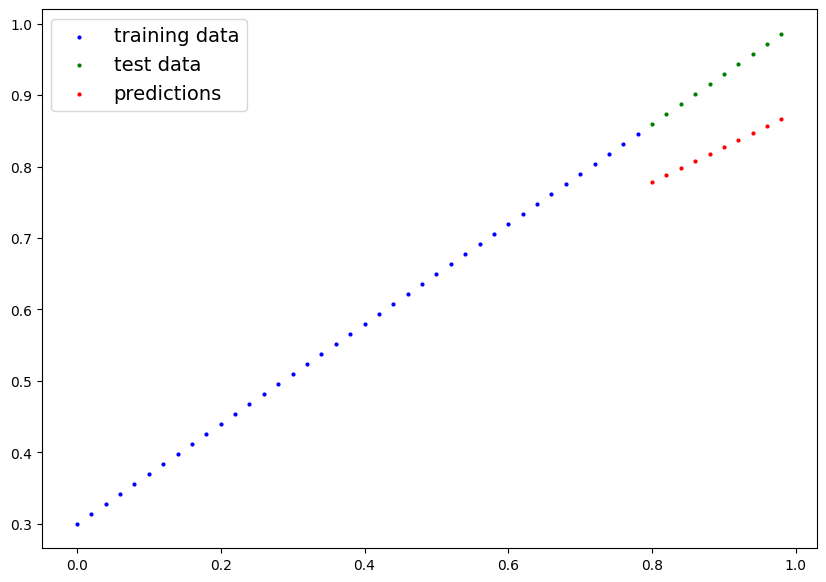

In [ ]:
plot_predictions(predictions=test_pred2)

In [ ]:

epochs = 100

# training
for epoch in range(epochs):
  # set the model to training mode
  model.train()  # dropout gibi bazı katmanların davranışını belirler, diğer mode model.eval()

  # 2. forward pass
  y_pred = model(X_train)

  # 3. calculate the loss
  loss = loss_fn(y_pred,y_train)
  print(f"loss: {loss}")

  # 4. optimizer zero grad
  optimizer.zero_grad()

  # 5. perform backpropagation on the loss
  loss.backward()

  # 6. perform gradient descent (step the optimizer)
  optimizer.step()

  # 7. testing
  model.eval()  # turns off different settings in the model not needed for evaluation/testing (dropout/batch norm layers)

  with torch.inference_mode():   # turns off gradient tracking
    # 7.1. testing forward pass
    test_pred = model(X_test)

    # 7.2. test loss
    test_loss = loss_fn(test_pred,y_test)

  if epoch % 10 == 0:
    print(f"epoch: {epoch}   Test loss:{test_loss}    Train loss:{loss}")

    print(model.state_dict())


loss: 0.04167863354086876
epoch: 0   Test loss:0.09919948130846024    Train loss:0.04167863354086876
OrderedDict({'weights': tensor([0.4938]), 'bias': tensor([0.3843])})
loss: 0.04132963344454765
loss: 0.04098063334822655
loss: 0.04063162952661514
loss: 0.040282636880874634
loss: 0.039933640509843826
loss: 0.03958464413881302
loss: 0.03923564404249191
loss: 0.03888664394617081
loss: 0.0385376438498497
loss: 0.03818932920694351
epoch: 10   Test loss:0.08886633068323135    Train loss:0.03818932920694351
OrderedDict({'weights': tensor([0.5116]), 'bias': tensor([0.3788])})
loss: 0.03785243630409241
loss: 0.0375034399330616
loss: 0.037164121866226196
loss: 0.03681822493672371
loss: 0.03647511452436447
loss: 0.03613303601741791
loss: 0.03578609973192215
loss: 0.03544783592224121
loss: 0.035098835825920105
loss: 0.03476089984178543
epoch: 20   Test loss:0.0805937647819519    Train loss:0.03476089984178543
OrderedDict({'weights': tensor([0.5288]), 'bias': tensor([0.3718])})
loss: 0.03441363573

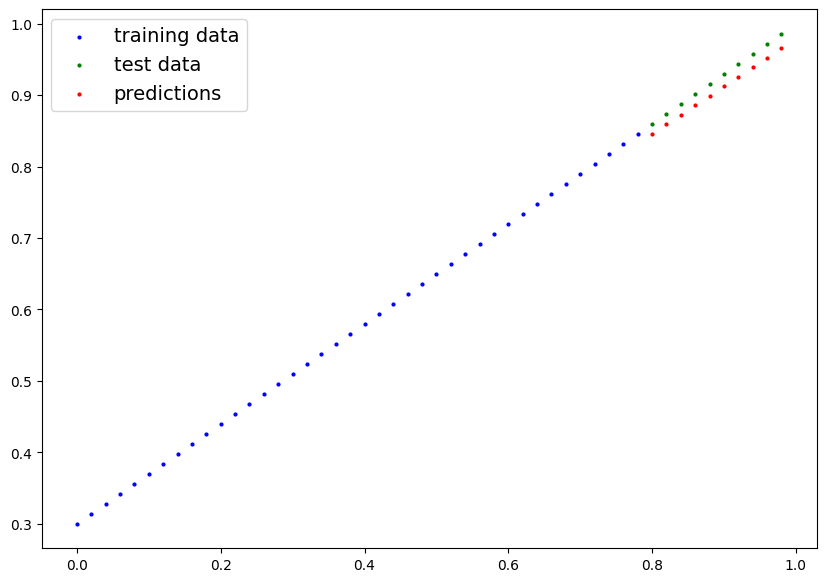

In [ ]:
with torch.inference_mode():
  y_preds_final = model(X_test)

plot_predictions(predictions=y_preds_final)

In [ ]:
epoch_count = []
train_loss_values = []
test_loss_values = []


epochs = 100

# training
for epoch in range(epochs):
  # set the model to training mode
  model.train()  # dropout gibi bazı katmanların davranışını belirler, diğer mode model.eval

  # 2. forward pass
  y_pred = model(X_train)

  # 3. calculate the loss
  loss = loss_fn(y_pred,y_train)


  # 4. optimizer zero grad
  optimizer.zero_grad()

  # 5. perform backpropagation on the loss
  loss.backward()

  # 6. perform gradient descent (step the optimizer)
  optimizer.step()

  # 7. testing
  model.eval()  # turns off different settings in the model not needed for evaluation/testing (dropout/batch norm layers)

  with torch.inference_mode():   # turns off gradient tracking
    # 7.1. testing forward pass
    test_pred = model(X_test)

    # 7.2. test loss
    test_loss = loss_fn(test_pred,y_test)

  if epoch % 10 == 0:
    print(f"epoch: {epoch}   Test loss:{test_loss}    Train loss:{loss}")
    epoch_count.append(epoch)
    # torch ile bağını kopartıyoruz, yoksa torch gradyan matplotlibe izin vermez. aşağıda açıklaması var
    train_loss_values.append(loss.item())
    test_loss_values.append(test_loss.item())


epoch: 0   Test loss:0.016474086791276932    Train loss:0.0072835334576666355
epoch: 10   Test loss:0.008201557211577892    Train loss:0.0038517764769494534
epoch: 20   Test loss:0.005023092031478882    Train loss:0.008932482451200485
epoch: 30   Test loss:0.005023092031478882    Train loss:0.008932482451200485
epoch: 40   Test loss:0.005023092031478882    Train loss:0.008932482451200485
epoch: 50   Test loss:0.005023092031478882    Train loss:0.008932482451200485
epoch: 60   Test loss:0.005023092031478882    Train loss:0.008932482451200485
epoch: 70   Test loss:0.005023092031478882    Train loss:0.008932482451200485
epoch: 80   Test loss:0.005023092031478882    Train loss:0.008932482451200485
epoch: 90   Test loss:0.005023092031478882    Train loss:0.008932482451200485


....
train_loss_values.append(loss)
test_loss_values.append(test_loss)
...

plt.plot(epoch_count,train_loss_values,label="train loss")
plt.plot(epoch_count,test_loss_values,label="test loss")
plt.title("Training and Test Loss Curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()

RuntimeError: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.


Harika bir hata yakaladın! Aslında bu hatayı alman o kadar iyi oldu ki; az önce konuştuğumuz o "PyTorch'un Not Defteri (Computation Graph)" ve `.numpy()` konularının sahada birebir ispatını yaşamış oldun.

Hata mesajı sana tam olarak şunu bağırıyor: *"Ben Matplotlib'im, grafiği çizmek için bana verdiğin listeyi arka planda NumPy array'ine çevirmek zorundayım. Ama içindeki tensörlerin hala türev (grad) takibi açık! PyTorch bana izin vermiyor!"*

### Neden Böyle Oldu?

Eğitim döngüsünün (training loop) içinde, her adımda hesaplanan o `loss` değerini bir listeye eklerken muhtemelen şöyle yazdın:
`train_loss_values.append(loss)`

Sorun şu ki; o `loss` sadece masum bir sayı değil. Üzerinde koca bir PyTorch türev grafiği (not defteri) taşıyan ağır bir objedir. Matplotlib bu objeyi doğrudan çizemez.

### Çözüm: "Bana Sadece Sayıyı Ver" (`.item()`)

Sektörde, özellikle sadece tek bir sayıdan (skaler) oluşan tensörleri (loss gibi) bu PyTorch yüklerinden kurtarıp **dümdüz ve saf bir Python tam sayısına / ondalık sayısına (float)** çevirmek için o meşhur "kurşun geçirmez taktiğin" en şık halini kullanırız: **`.item()`**

Eğitim döngünde (Training Loop) listeye ekleme yaptığın o satırları şu şekilde değiştirmelisin:

**Yanlış Kullanım (Senin yaptığın):**

```python
train_loss_values.append(loss)
test_loss_values.append(test_loss)

```

**Doğru Kullanım (Sektör Standardı):**

```python
# .item() diyerek o tensörün içindeki saf sayıyı çekip alıyoruz
# Artık gradyanmış, PyTorch hafızasıymış hiçbir bağı kalmadı!
train_loss_values.append(loss.item())
test_loss_values.append(test_loss.item())

```

*(Alternatif olarak hata mesajının önerdiği gibi `loss.detach().numpy()` de kullanabilirdin ama tek bir sayı çekiyorsan `.item()` yazmak çok daha kısa ve temizdir).*

### Şimdiki Listeyi Nasıl Kurtarırsın?

Eğer o 100 epoch'luk döngüyü tekrar çalıştırmak istemiyorsan, elindeki şu anki hatalı listeyi grafiğe vermeden hemen önce Python'ın yeHarika bir hata yakaladın! Aslında bu hatayı alman o kadar iyi oldu ki; az önce konuştuğumuz o "PyTorch'un Not Defteri (Computation Graph)" ve `.numpy()` konularının sahada birebir ispatını yaşamış oldun.

Hata mesajı sana tam olarak şunu bağırıyor: *"Ben Matplotlib'im, grafiği çizmek için bana verdiğin listeyi arka planda NumPy array'ine çevirmek zorundayım. Ama içindeki tensörlerin hala türev (grad) takibi açık! PyTorch bana izin vermiyor!"*

### Neden Böyle Oldu?

Eğitim döngüsünün (training loop) içinde, her adımda hesaplanan o `loss` değerini bir listeye eklerken muhtemelen şöyle yazdın:
`train_loss_values.append(loss)`

Sorun şu ki; o `loss` sadece masum bir sayı değil. Üzerinde koca bir PyTorch türev grafiği (not defteri) taşıyan ağır bir objedir. Matplotlib bu objeyi doğrudan çizemez.

### Çözüm: "Bana Sadece Sayıyı Ver" (`.item()`)

Sektörde, özellikle sadece tek bir sayıdan (skaler) oluşan tensörleri (loss gibi) bu PyTorch yüklerinden kurtarıp **dümdüz ve saf bir Python tam sayısına / ondalık sayısına (float)** çevirmek için o meşhur "kurşun geçirmez taktiğin" en şık halini kullanırız: **`.item()`**

Eğitim döngünde (Training Loop) listeye ekleme yaptığın o satırları şu şekilde değiştirmelisin:

**Yanlış Kullanım (Senin yaptığın):**

```python
train_loss_values.append(loss)
test_loss_values.append(test_loss)

```

**Doğru Kullanım (Sektör Standardı):**

```python
# .item() diyerek o tensörün içindeki saf sayıyı çekip alıyoruz
# Artık gradyanmış, PyTorch hafızasıymış hiçbir bağı kalmadı!
train_loss_values.append(loss.item())
test_loss_values.append(test_loss.item())

```

*(Alternatif olarak hata mesajının önerdiği gibi `loss.detach().numpy()` de kullanabilirdin ama tek bir sayı çekiyorsan `.item()` yazmak çok daha kısa ve temizdir).*

### Şimdiki Listeyi Nasıl Kurtarırsın?

Eğer o 100 epoch'luk döngüyü tekrar çalıştırmak istemiyorsan, elindeki şu anki hatalı listeyi grafiğe vermeden hemen önce Python'ın yetenekleriyle hızlıca saf sayılara (veya NumPy'a) dönüştürebilirsin:

```python
import torch
import numpy as np

# Listendeki tüm türevli tensörleri numpy array'ine çevirip bağlarını koparıyoruz
with torch.inference_mode():
    train_loss_values_np = torch.tensor(train_loss_values).numpy()
    test_loss_values_np = torch.tensor(test_loss_values).numpy()

# Şimdi Matplotlib'e bu temizlenmiş verileri ver
plt.plot(epoch_count, train_loss_values_np, label="train loss")
plt.plot(epoch_count, test_loss_values_np, label="test loss")
plt.title("Training and Test Loss Curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()

```

Bu ufak dokunuşu (özellikle `.item()` taktiğini) döngüne eklediğinde o efsanevi, aşağı doğru süzülen öğrenme (loss) eğrisini göreceksin!

Grafik çizildiğinde, `test_loss` çizgisinin `train_loss` çizgisini ne kadar yakından takip ettiğine (overfitting olup olmadığına) ve modelin bulduğu nihai parametrelerin (weight/bias) hedefe ne kadar yaklaştığına bakıp bu ilk modelinin başarısını birlikte değerlendirelim mi?tenekleriyle hızlıca saf sayılara (veya NumPy'a) dönüştürebilirsin:

```python
import torch
import numpy as np

# Listendeki tüm türevli tensörleri numpy array'ine çevirip bağlarını koparıyoruz
with torch.inference_mode():
    train_loss_values_np = torch.tensor(train_loss_values).numpy()
    test_loss_values_np = torch.tensor(test_loss_values).numpy()

# Şimdi Matplotlib'e bu temizlenmiş verileri ver
plt.plot(epoch_count, train_loss_values_np, label="train loss")
plt.plot(epoch_count, test_loss_values_np, label="test loss")
plt.title("Training and Test Loss Curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()

```

Bu ufak dokunuşu (özellikle `.item()` taktiğini) döngüne eklediğinde o efsanevi, aşağı doğru süzülen öğrenme (loss) eğrisini göreceksin!

Grafik çizildiğinde, `test_loss` çizgisinin `train_loss` çizgisini ne kadar yakından takip ettiğine (overfitting olup olmadığına) ve modelin bulduğu nihai parametrelerin (weight/bias) hedefe ne kadar yaklaştığına bakıp bu ilk modelinin başarısını birlikte değerlendirelim mi?


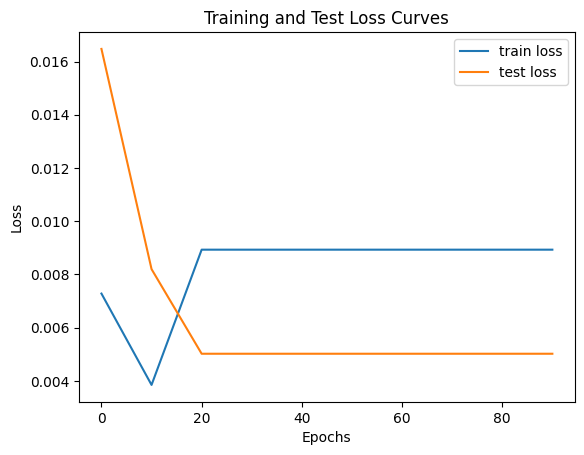

In [ ]:
# graphic

plt.plot(epoch_count,train_loss_values,label="train loss")
plt.plot(epoch_count,test_loss_values,label="test loss")
plt.title("Training and Test Loss Curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

In [ ]:
# saving and loading model

# 3 three main core functions
# torch.save() ---> saving a PyTorch object as like Python's pickle format
# torch.load() ---> loading a saved PyTorch object
# torch.nn.Module.load_state_dict() ---> loading a model's saved state dictionary

model.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [ ]:
# saving
from pathlib import Path

# create models directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True,exist_ok=True)

# model save path
MODEL_NAME = "01_pytorch_workflow_model.pth"  # .pth veya .pt kullanırız
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

MODEL_SAVE_PATH

# saving the model state dict
print("saving...")
torch.save(obj=model.state_dict(),
           f=MODEL_SAVE_PATH)

saving...


In [ ]:
!ls -l models  # model kaydedilmiş mi diye check et

total 4
-rw-r--r-- 1 root root 2101 Mar  6 12:00 01_pytorch_workflow_model.pth


In [ ]:
# loading

# modelimizi state_dict() olarak kaydettik, tüm modeli kaydetmek yerine bu yüzden model class'dan yeni obje oluşturup, ağırlıkları ona verecez

model.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [ ]:
loaded_model = LinearRegressionModel()

loaded_model.state_dict()  # random değerlerle başladı

OrderedDict([('weights', tensor([0.2345])), ('bias', tensor([0.2303]))])

In [ ]:
loaded_model.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

<All keys matched successfully>

In [ ]:
loaded_model.state_dict()  # kaydedilen ağırlıkları verdik

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [ ]:
# prediction for sure

loaded_model.eval()

with torch.inference_mode():
  loaded_model_preds = loaded_model(X_test)

loaded_model_preds

tensor([[0.8685],
        [0.8825],
        [0.8965],
        [0.9105],
        [0.9245],
        [0.9384],
        [0.9524],
        [0.9664],
        [0.9804],
        [0.9944]])

In [ ]:
# compare

model.eval()

with torch.inference_mode():
  y_pred = model(X_test)

y_pred == loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

# putting all together


In [ ]:
import torch
from torch import nn
import matplotlib.pyplot as plt
import numpy as np

torch.__version__

'2.10.0+cpu'

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [ ]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [ ]:
weight = 0.7
bias = 0.3
start = 0.0
end = 1.0
step = 0.02

X = torch.arange(start,end,step).unsqueeze(dim=1)
X.shape

torch.Size([50, 1])

In [ ]:
y = weight * X + bias

train_split = int(0.8 * len(X))

X_train = X[:train_split]
X_test = X[train_split:]
y_train = y[:train_split]
y_test = y[train_split:]

print(len(X_train),len(X_test),len(y_train),len(y_test))

40 10 40 10


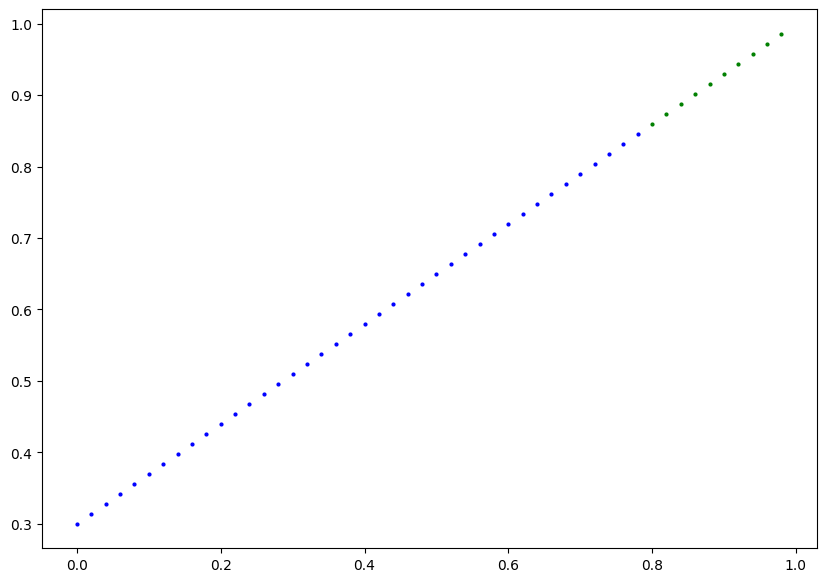

In [ ]:
def plot_predictions(train_data=X_train,
                   train_labels=y_train,
                     test_data = X_test,
                     test_labels = y_test,
                     prediction = None):
  plt.figure(figsize=(10,7))
  plt.scatter(train_data,train_labels,c="b",s=4,label="training data")
  plt.scatter(test_data,test_labels,c="g",s=4,label="test data")
  if prediction is not None:
    plt.scatter(X_test,prediction,c="r",s=4,label="prediction")

plot_predictions()

In [ ]:
class LinearRegressionModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    """
    self.weight = torch.randn(1,
                              requires_grad=True,
                              type=torch.float)
    self.bias = torch.randn(1,
                            requires_grad=True,
                            type=torch.float)
    """
    # use nn.Linear() for creating the model parameters
    # y = x * A.T + b demek nn.Linear
    # parametre başlatmıyoruz, layer başlatıyoruz (initialize layers)
    self.linear_layer = nn.Linear(in_features=1,
                                  out_features=1)

  def forward(self, x:torch.Tensor) -> torch.Tensor:
    return self.linear_layer(x)


torch.manual_seed(42)
model1 = LinearRegressionModelV2()
model1

LinearRegressionModelV2(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

In [ ]:
model1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
             ('linear_layer.bias', tensor([0.8300]))])

In [ ]:
model1.to(device)

LinearRegressionModelV2(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

In [ ]:
next(model1.parameters()).device

device(type='cpu')

In [ ]:
# model ve data aynı cihazda olmalı

# put data on the target device
X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

In [ ]:
loss = nn.L1Loss()

optimizer = torch.optim.Adam(params=model1.parameters(),
                             lr = 0.01)

In [ ]:
torch.manual_seed(42)

epochs = 200


for epoch in range(epochs):
  # train loop
  model1.train()
  y_pred = model1(X_train)
  loss_train = loss(y_pred,y_train)
  optimizer.zero_grad()  # default ayarı optimizer'ın gradient accumulation
  loss_train.backward()
  optimizer.step()

  # test loop
  model1.eval()
  with torch.inference_mode():
    tess_pred = model1(X_test)
    loss_test = loss(tess_pred,y_test)

  if epoch%10 == 0:
    print(f"epoch:{epoch}")
    print(f"train loss:{loss_train}")
    print(f"test loss:{loss_test}")


epoch:0
train loss:0.5551779866218567
test loss:0.568547248840332
epoch:10
train loss:0.4161780774593353
test loss:0.3795473873615265
epoch:20
train loss:0.27717819809913635
test loss:0.19054758548736572
epoch:30
train loss:0.13817831873893738
test loss:0.012273055501282215
epoch:40
train loss:0.06483234465122223
test loss:0.15948258340358734
epoch:50
train loss:0.06953977048397064
test loss:0.19462481141090393
epoch:60
train loss:0.0556403286755085
test loss:0.14198976755142212
epoch:70
train loss:0.0445832721889019
test loss:0.08211381733417511
epoch:80
train loss:0.03573416918516159
test loss:0.06503848731517792
epoch:90
train loss:0.025599658489227295
test loss:0.05930420011281967
epoch:100
train loss:0.015041215345263481
test loss:0.02901391312479973
epoch:110
train loss:0.004283720161765814
test loss:0.008546513505280018
epoch:120
train loss:0.0037691467441618443
test loss:0.009793078526854515
epoch:130
train loss:0.0002783544478006661
test loss:0.0004135310591664165
epoch:140
tr

In [ ]:
model1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6953]])),
             ('linear_layer.bias', tensor([0.3000]))])

In [ ]:
weight,bias

(0.7, 0.3)

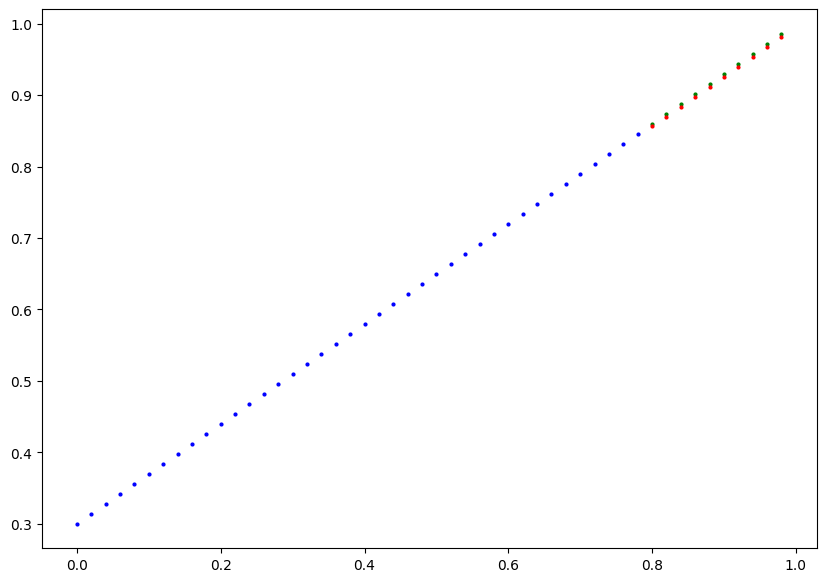

In [ ]:
model.eval()
with torch.inference_mode():
  y_preds = model1(X_test)

# .cpu yazma nedenimiz, eğer gpu üstünde olursa matplotlib numpy beklediği için hata verecek olması
plot_predictions(prediction=y_preds.cpu())

In [ ]:
from pathlib import Path

model_path = Path("models")
model_path.mkdir(parents=True,exist_ok=True)

model_name = "01_pytorch_workflow_model_v2.pth"
model_save_path = model_path / model_name

torch.save(obj = model1.state_dict(),
           f=model_save_path)

In [ ]:
loaded_model1 = LinearRegressionModelV2()

loaded_model1.load_state_dict(torch.load(f=model_save_path))

loaded_model1.to(device)

loaded_model1

LinearRegressionModelV2(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

In [ ]:
loaded_model1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6953]])),
             ('linear_layer.bias', tensor([0.3000]))])

In [ ]:
loaded_model1.eval()

with torch.inference_mode():
  y_preds2 = loaded_model1(X_test)

y_preds == y_preds2

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

In [ ]:
# exercises kısmına da bak